In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
#Loading the Dataset
df=pd.read_csv("Breast_cancer_dataset.csv")
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [3]:
#Acquiring Datatype Info from the Dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [4]:
#Acquiring Statistical Info
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [5]:
#Check for Missing Values
print(df.isnull().sum())
#There are no null/missing values

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

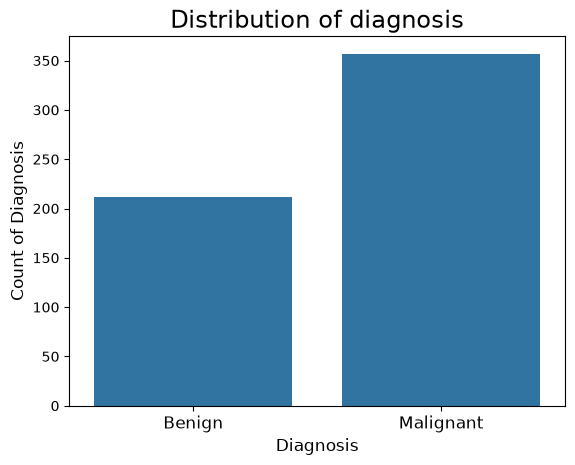

In [6]:
#Distribution of the target variable
sns.countplot(x="diagnosis", data=df)
plt.title("Distribution of diagnosis",fontsize=17,c="k")
plt.xlabel("Diagnosis",fontsize=12)
plt.ylabel("Count of Diagnosis",fontsize=12)
plt.xticks([0,1], ['Benign','Malignant'],fontsize=12)
plt.show()
#The plot shows the distribution of the Target variable "diagnosis",highlighting the count of benign and malignant cases.


In [7]:
#Identifying the countsof target variable from the plot
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [8]:
#Remove Unwanted Columns from the dataset
df=df.drop(["Unnamed: 32","id"],axis=1)

In [9]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


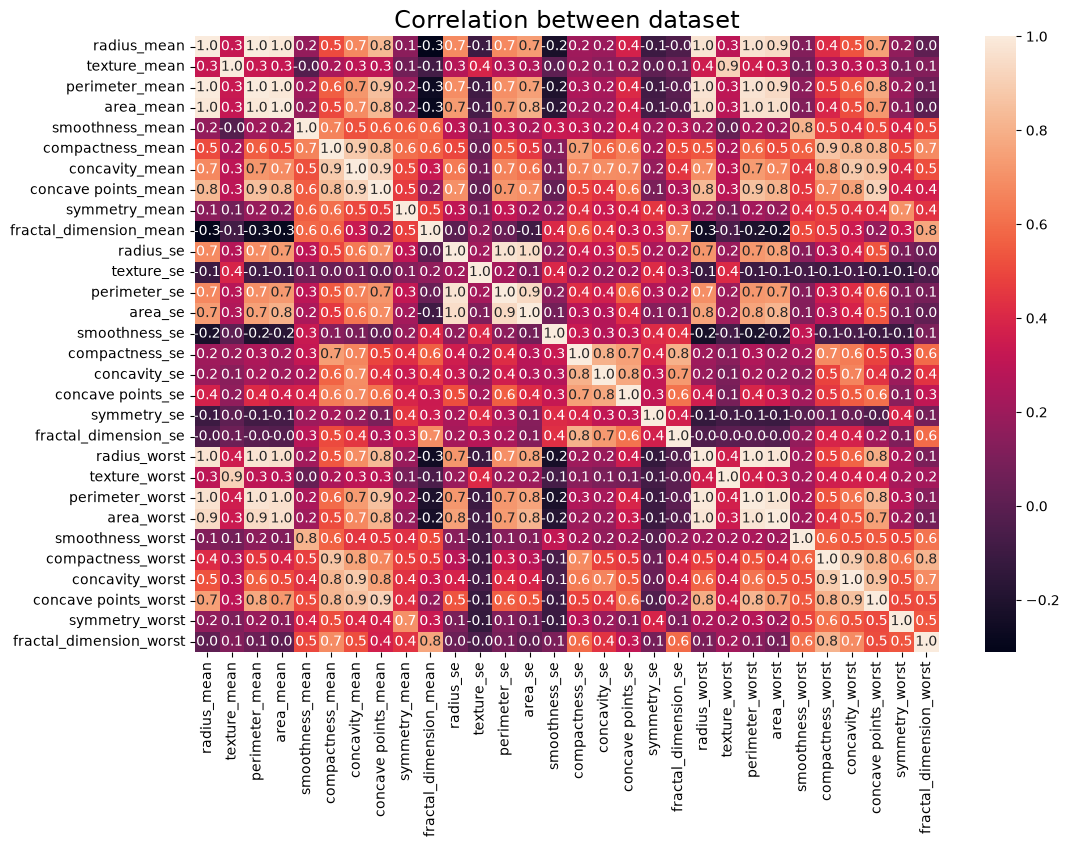

In [10]:
#Plotting Correlation map to understand the relationship between features
plt.figure(figsize=(12,8))
c=df.corr(numeric_only=True)
sns.heatmap(c,annot=True,fmt=".1f")
plt.title("Correlation between dataset",fontsize=17,c="k")
plt.show()


Observation:

High Correlations: Several pairs of features exhibit strong positive correlations. For example, radius_mean, perimeter_mean, and area_mean are highly correlated with each other. This is expected as these are all measures of size and dimensions of the detected tumors.

Feature Groups: Features related to the "worst" (largest value of these features for each image), "mean", and "error" (standard error) calculations are grouped together, indicating that similar types of measurements are highly correlated. For example, radius_worst, perimeter_worst, and area_worst also show very high positive correlations.

Clinical Relevance: High correlations between features like concavity_mean and concave points_mean suggest that more concave portions of the tumor outline correspond to more frequent concave points, which are relevant characteristics for diagnosing malignancy of the sample.

Convert Categorical variable diagnosis into one-hot encoded numerical variable with benign instances assigned 0 and malignant 1

In [11]:
#Transform diagnosis column into numeric 
Encoder=LabelEncoder()
df["diagnosis"]=Encoder.fit_transform(df["diagnosis"])
df["diagnosis"]

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [12]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
#Split the data into Feature(X) and  Target(y)
X=df.drop("diagnosis",axis=1)
y=df["diagnosis"]

In [14]:
#Split the dataset into training and testing datasets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('log_reg',LogisticRegression(max_iter=10000,random_state=42))
    ])

In [16]:
#Fit the Pipeline on the training data
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [17]:
#Predict on the Training and Testing dataset
y_pred_train=pipeline.predict(X_train)
y_pred_test=pipeline.predict(X_test)

In [18]:
# Predict probabilities on the testing set
y_pred_test_prob = pipeline.predict_proba(X_test)[:, 1]

Create a DataFrame with actual labels, predicted scores, and predicted probabilities, for test data

    * The probabilities of the positive class (malignant) for the testing set are obtained, useful for further evaluation metrics like ROC-AUC.


In [19]:
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test,
    'Predicted Probability': y_pred_test_prob}
)
# Display the first 5 instances in the result dataframe
results_df.head()

,Actual Label,Predicted Label,Predicted Probability
204,0,0,0.113590
70,1,1,0.999991
131,1,1,0.996921
431,0,0,0.000510
540,0,0,0.000061


In [20]:
# Calculate the training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train)
testing_accuracy = accuracy_score(y_test, y_pred_test)

print("Logistic Regression")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

Logistic Regression
Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.9736842105263158


Observation:
Training Accuracy (98.68%):

Indicates that the logistic regression model correctly classifies 98.68% of the training instances. A high training accuracy suggests that the model has learned the patterns present in the training data well.

Testing Accuracy (97.37%):

This indicates that the model correctly classifies 97.37% of the instances in the test set, which was not seen during training. High testing accuracy suggests that the model generalizes well to new, unseen data.

Model Performance:

Both training and testing accuracies are high, indicating good overall performance of the logistic regression model. The slight drop from training to testing accuracy (from 98.68% to 97.37%) is expected and acceptable, showing that the model generalizes well without overfitting.

Check for Overfitting:

If the training accuracy were significantly higher than the testing accuracy, it would suggest overfitting. However, in this case, the difference is small, indicating that the model is not overfitting.

Confusion Matrix:
[[70  1]
 [ 2 41]]


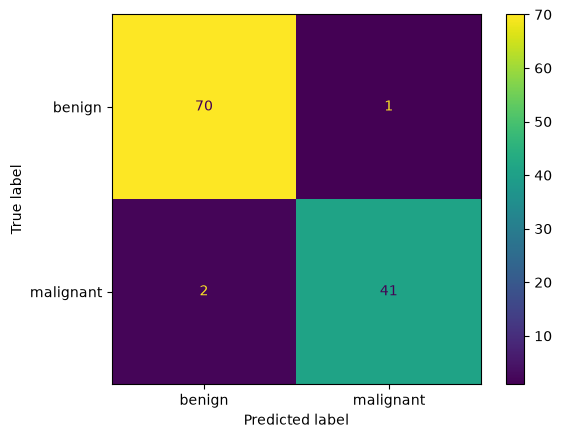

In [23]:
#Print Confusion Matrix
conf_matrix=confusion_matrix(y_test,y_pred_test)
print("Confusion Matrix:")
print(conf_matrix)

#Heatmap Visualization for  Confusion Matrix
cm_display=ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=["benign","malignant"])

#display matrix
cm_display.plot()
plt.show()


**Logistic Regression Classification Report**

**Class 0 (Negative Class)**

- **Precision: 0.97**

  97% of the instances predicted as class 0 are actually class 0.

- **Recall: 0.99**

  99% of the actual class 0 instances are correctly predicted as class 0.

- **F1-Score: 0.98**

  The F1-score is the harmonic mean of precision and recall, providing a balance between the two metrics. Here, the F1-score is 0.98, indicating excellent performance.

- **Support: 71**

  There are 71 actual instances of class 0 in the test set.

**Class 1 (Positive Class)**

- **Precision: 0.98**

  98% of the instances predicted as class 1 are actually class 1.

- **Recall: 0.95**

  95% of the actual class 1 instances are correctly predicted as class 1.

- **F1-Score: 0.96**

  The F1-score for class 1 is 0.96, indicating very good performance.

- **Support: 43**

  There are 43 actual instances of class 1 in the test set.

**Overall Metrics**

- **Accuracy: 0.97**

  The overall accuracy of the model, indicating that 97% of the total instances are correctly classified.

- **Macro Average**

  Macro average calculates the metric independently for each class and then takes the average, treating all classes equally. It is useful when you have imbalanced classes.

  **Precision: 0.97**  
  **Recall: 0.97**  
  **F1-Score: 0.97**

- **Weighted Average**

  Weighted average takes into account the support (the number of true instances for each class) to calculate the average. It is more representative of the performance on imbalanced datasets.

  **Precision: 0.97**  
  **Recall: 0.97**  
  **F1-Score: 0.97**


Optimal Threshold: 0.4848


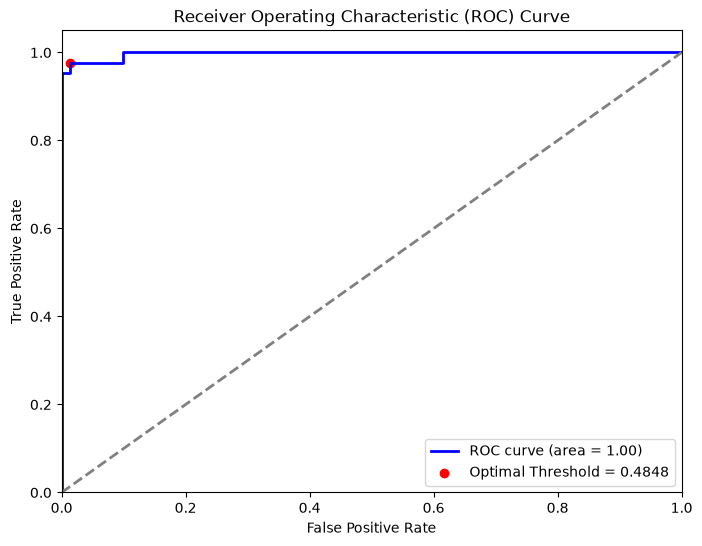

In [25]:
#Plot the ROC Curve
# Compute the false positive rate (fpr), true positive rate (tpr), and thresholds for different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_prob)

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Observation:
The ROC curve in the image reaches the top-left corner (TPR = 1, FPR = 0), which indicates a perfect classification performance. The model perfectly distinguishes between the positive and negative classes at various threshold settings.

The ROC curve for the logistic regression model has AUC of 1.00. This indicates that the model has perfect discriminatory power. An AUC of 1 means the model correctly classifies all positive and negative instances without error.

The Optimal threshold of 0.4867 defines the decision boundary for the classifier. Probabilities above this value indicate a stronger belief that an instance belongs to the positive class, whereas probabilities below this value indicate a stronger belief that an instance belongs to the negative class.

In [27]:
# Apply Naive Bayes algorithm
# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('nb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [29]:
#Predict on the training and testing set
y_pred_train_nb = pipeline.predict(X_train)
y_pred_test_nb = pipeline.predict(X_test)

# Calculate the training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_nb)
testing_accuracy = accuracy_score(y_test, y_pred_test_nb)
print("\nNaïve Bayes:")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

y_pred_prob_nb = pipeline.predict_proba(X_test)[:, 1]


Naïve Bayes:
Training Accuracy: 0.9362637362637363
Testing Accuracy: 0.9649122807017544


Observation
The training accuracy (93.63%) and testing accuracy (96.49%) are relatively close to each other. This suggests that the model is not overfitting to the training data, as the performance on the testing set is slightly better or comparable to the training set.

In [30]:
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_nb,
    'Predicted Probability': y_pred_prob_nb
})

results_df.head()

,Actual Label,Predicted Label,Predicted Probability
204,0,0,1.349483e-09
70,1,1,1.000000e+00
131,1,1,1.000000e+00
431,0,0,9.801091e-12
540,0,0,8.102568e-15


#### __Observation__

- The Naive Bayes classifier computes the probability of a class given the input features by multiplying the individual conditional probabilities of each feature.

- Internally, many Naive Bayes implementations use logarithms to prevent numerical underflow when multiplying many small probabilities. The extreme values observed might be a result of the conversion back from logarithmic space to probability space.


Confusion Matrix:
[[70  1]
 [ 3 40]]


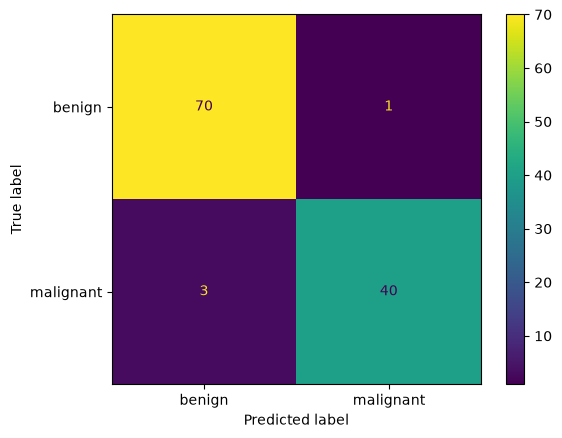

In [31]:
# Print confusion matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_test_nb)
print("Confusion Matrix:")
print(conf_matrix_nb)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_nb, display_labels = ["benign", "malignant"])
# display matrix
cm_display.plot()
plt.show()

In [32]:
# Print classification report
print("\t\tNaïve Bayes Classification Report:")
print("\t\t-----------------------------------")
print(classification_report(y_test, y_pred_test_nb))

		Naïve Bayes Classification Report:
		-----------------------------------
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Optimal Threshold: 0.0126


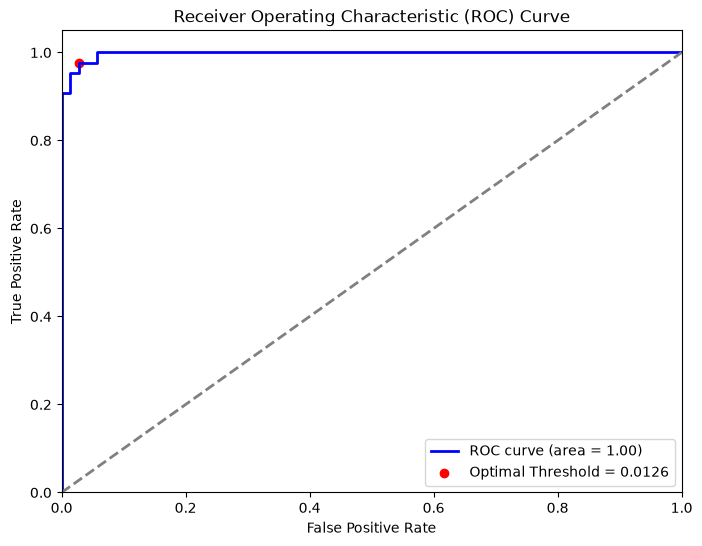

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_nb)

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Observation:

- The ROC curve for the Naive Bayes classifier demonstrates outstanding performance, with an AUC of 1.00 indicating perfect classification ability on the breast cancer dataset.

- This implies that the model is highly effective in distinguishing between benign and malignant cases with no errors.

- Optimal threshold is 0.0126. Some models, such as Naive Bayes, often produce uncalibrated probabilities that tend to be extreme (close to 0 or 1). This can result in needing a very low threshold to balance sensitivity and specificity effectively.

In [36]:
# Aply K-Nearest Neighbors

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),   # Standardize the data
    ('knn', KNeighborsClassifier(n_neighbors=3)) # KNN classifier
])
pipeline_knn.fit(X_train, y_train)

# Predict on the training and testing set
y_pred_train_knn = pipeline_knn.predict(X_train)
y_pred_test_knn = pipeline_knn.predict(X_test)

In [37]:
# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_knn)
testing_accuracy = accuracy_score(y_test, y_pred_test_knn)
print("\nK-Nearest Neighbors (KNN)")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

y_pred_prob_knn = pipeline_knn.predict_proba(X_test)[:, 1]


K-Nearest Neighbors (KNN)
Training Accuracy: 0.9846153846153847
Testing Accuracy: 0.9473684210526315


In [38]:
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_knn,
    'Predicted Probability': y_pred_prob_knn
})

results_df.head()

,Actual Label,Predicted Label,Predicted Probability
204,0,0,0.0
70,1,1,1.0
131,1,1,1.0
431,0,0,0.0
540,0,0,0.0


In [39]:
len(results_df[(results_df["Actual Label"] == 1) & (results_df["Predicted Label"] == 1)])

40

Confusion Matrix:
[[68  3]
 [ 3 40]]


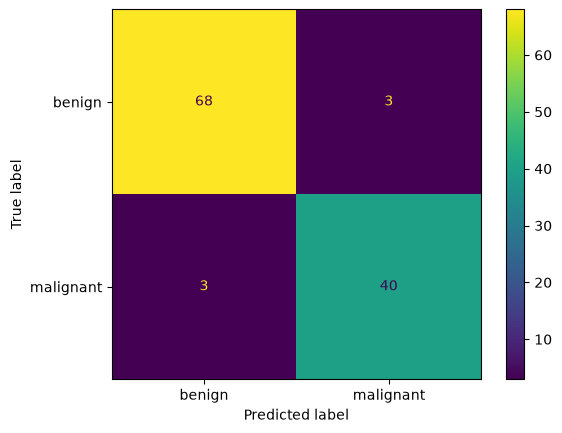

In [40]:
# Print confusion matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_test_knn)
print("Confusion Matrix:")
print(conf_matrix_knn)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_knn, display_labels = ["benign", "malignant"])
# display matrix
cm_display.plot()
plt.show()


In [41]:
# Print classification report
print("\t\tK-Nearest Neighbors Classification Report:")
print("\t\t-----------------------------------")
print(classification_report(y_test, y_pred_test_knn))

		K-Nearest Neighbors Classification Report:
		-----------------------------------
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



#### __Observation__

**Metrics for Each Class:**

**Class 0 (Benign):**
- **Precision: 0.96**
  - **Meaning**: Of all the instances predicted as class 0, 96% were correctly classified. Precision measures the accuracy of the positive predictions.
- **Recall: 0.96**
  - **Meaning**: Of all the actual instances of class 0, 96% were correctly identified by the model. Recall measures the model's ability to find all the relevant cases within a class.
- **F1-Score: 0.96**
  - **Meaning**: The F1-score is the harmonic mean of precision and recall. An F1-score of 0.96 indicates a good balance between precision and recall for class 0.
- **Support: 71**
  - **Meaning**: There are 71 instances of class 0 in the test dataset.

**Class 1 (Malignant):**
- **Precision: 0.93**
  - **Meaning**: Of all the instances predicted as class 1, 93% were correctly classified.
- **Recall: 0.93**
  - **Meaning**: Of all the actual instances of class 1, 93% were correctly identified by the model.
- **F1-Score: 0.93**
  - **Meaning**: An F1-score of 0.93 indicates a good balance between precision and recall for class 1.
- **Support: 43**
  - **Meaning**: There are 43 instances of class 1 in the test dataset.

**Overall Metrics:**

- **Accuracy: 0.95**
  - **Meaning**: The overall accuracy of the model is 95%, indicating that 95% of the total instances in the test dataset were correctly classified by the model.

- **Macro Average:**
  - **Precision: 0.94**
  - **Recall: 0.94**
  - **F1-Score: 0.94**
    

- **Weighted Average:**
  - **Precision: 0.95**
  - **Recall: 0.95**
  - **F1-Score: 0.95**
    


Optimal Threshold: 0.3333


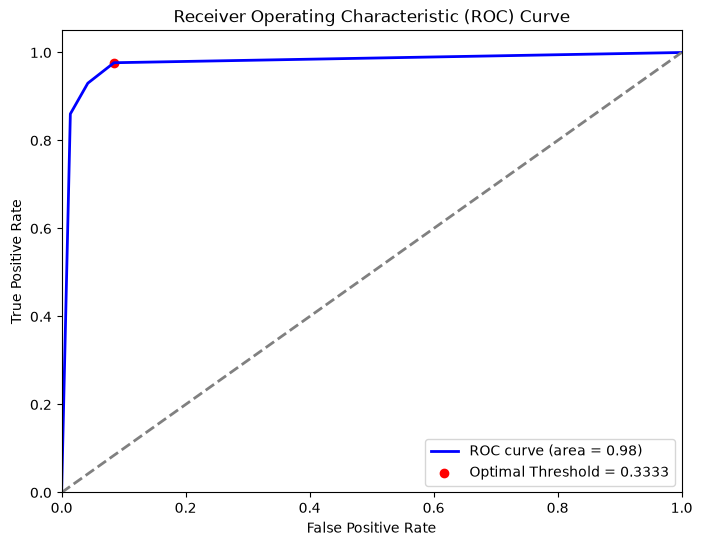

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_knn)
roc_auc = auc(fpr, tpr)

# Find the optimal threshold by maximizing Youden's  statistic
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

#### __Observation__

- The ROC curve has a steep ascent to a high True Positive Rate with a low False Positive Rate, indicating that the classifier is effective at distinguishing between the positive and negative classes.

- The AUC value is 0.98, which is very close to 1.0. An AUC of 0.98 indicates excellent discriminatory ability, meaning the classifier is highly capable of distinguishing between the positive and negative classes.

- The optimal threshold for the KNN classifier, determined using Youden's J statistic, is 0.33.

In [58]:
#Import Required Libraries and apply decision tree
from sklearn.tree import DecisionTreeClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),   # Standardize the data
    ('dt', DecisionTreeClassifier()) # Decision Tree classifier
])
pipeline.fit(X_train, y_train)

# Predict on the training and testing set
y_pred_train_dt = pipeline.predict(X_train)
y_pred_test_dt = pipeline.predict(X_test)

# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_dt)
testing_accuracy = accuracy_score(y_test, y_pred_test_dt)
print("\nDecision Trees")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

y_pred_prob_dt = pipeline.predict_proba(X_test)[:, 1]



Decision Trees
Training Accuracy: 1.0
Testing Accuracy: 0.9385964912280702


In [59]:
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_dt,
    'Predicted Probability': y_pred_prob_dt
})

results_df.head()

,Actual Label,Predicted Label,Predicted Probability
204,0,0,0.0
70,1,1,1.0
131,1,1,1.0
431,0,0,0.0
540,0,0,0.0


### __Observation:__
- Training accuracy indicates that the decision tree model perfectly classifies the training data. This is a strong indicator of overfitting, where the model is too complex and captures noise in the training data, resulting in perfect accuracy.
- The testing accuracy, while still high, is lower than the training accuracy. This difference indicates that the model does not generalize as well to unseen data as it does to the training data, reinforcing the possibility of overfitting.

When there is a significant difference between training and testing accuracy (as seen with training accuracy at 1.0 and testing accuracy at 92%), it suggests that the model might be overfitting to the training data. Cross-validation helps confirm this by showing how the model performs on different subsets of the data.

- The primary goal of cross-validation is to assess how well the model generalizes to independent datasets. A model that performs well on cross-validation is more likely to generalize well to new, unseen data.

- Cross-validation helps in understanding the stability of the model’s performance. If the cross-validation scores vary significantly, it indicates that the model's performance is inconsistent and may depend heavily on the specific train-test split.

**Using cross_val_score with the pipeline and training data**

When using a pipeline, `cross_val_score` ensures that all steps in the pipeline (like scaling and model fitting) are applied consistently during each fold of the cross-validation process.

In [60]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.9010989  0.9010989  0.95604396 0.92307692 0.92307692]
Mean CV Score: 0.9208791208791209


-  The cross-validation scores are relatively consistent, with accuracies ranging from approximately 91.21% to 94.51%. This consistency indicates that the model is robust and performs well across different subsets of the data.

- The mean cross-validation score of approximately 92.31% suggests that the model generalizes well to unseen data, providing a reliable measure of its performance.

- Using cross-validation helps ensure that the performance estimate is not overly optimistic or pessimistic, giving a balanced view of the model's effectiveness.

Confusion Matrix:
[[67  4]
 [ 3 40]]


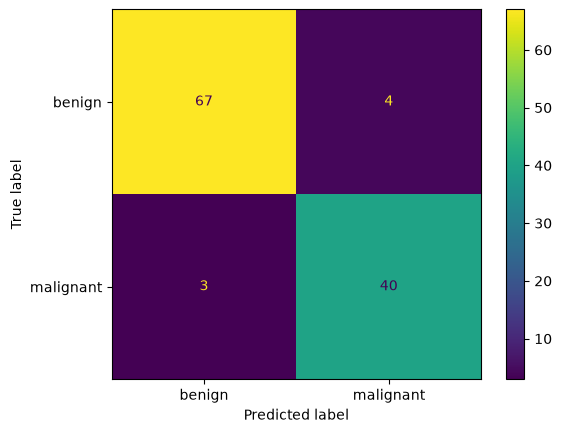

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

# Print confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_test_dt)
print("Confusion Matrix:")
print(conf_matrix_dt)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_dt, display_labels = ["benign", "malignant"])
# display matrix
cm_display.plot()
plt.show()

#### __Observation__

**Decision Trees Classification Report**

The classification report provides a detailed performance evaluation of the Decision Tree classifier on the test dataset. It includes various metrics: precision, recall, F1-score, and support for each class, along with overall metrics such as accuracy, macro average, and weighted average.

**Metrics for Each Class:**

**Class 0 (Benign):**
- **Precision: 0.94**
  - **Meaning**: Of all the instances predicted as class 0, 94% were correctly classified. Precision measures the accuracy of the positive predictions.
- **Recall: 0.94**
  - **Meaning**: Of all the actual instances of class 0, 94% were correctly identified by the model. Recall measures the model's ability to find all the relevant cases within a class.
- **F1-Score: 0.94**
  - **Meaning**: The F1-score is the harmonic mean of precision and recall. An F1-score of 0.94 indicates a good balance between precision and recall for class 0.
- **Support: 71**
  - **Meaning**: There are 71 instances of class 0 in the test dataset.

**Class 1 (Malignant):**
- **Precision: 0.91**
  - **Meaning**: Of all the instances predicted as class 1, 91% were correctly classified.
- **Recall: 0.91**
  - **Meaning**: Of all the actual instances of class 1, 91% were correctly identified by the model.
- **F1-Score: 0.91**
  - **Meaning**: An F1-score of 0.91 indicates a good balance between precision and recall for class 1.
- **Support: 43**
  - **Meaning**: There are 43 instances of class 1 in the test dataset.

**Overall Metrics:**

- **Accuracy: 0.93**
  - **Meaning**: The overall accuracy of the model is 93%, indicating that 93% of the total instances in the test dataset were correctly classified by the model.

**Macro Average:**
- **Precision: 0.93**
- **Recall: 0.93**
- **F1-Score: 0.93**
  

**Weighted Average:**
- **Precision: 0.93**
- **Recall: 0.93**
- **F1-Score: 0.93**
  


Optimal Threshold: 1.0000


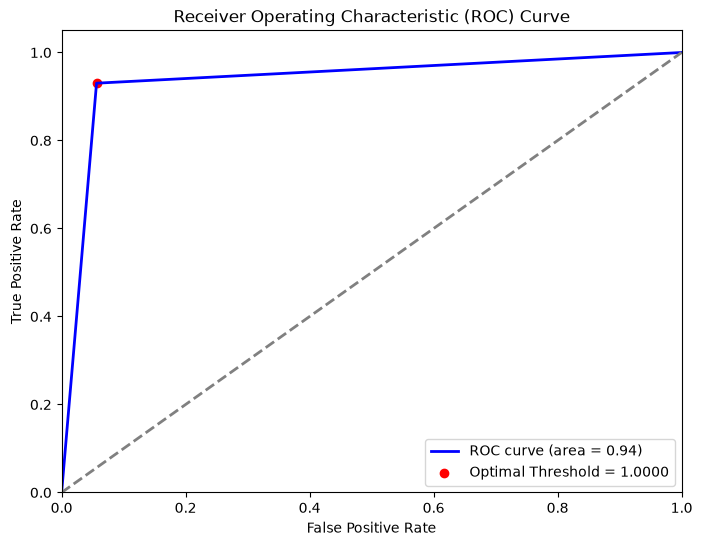

In [63]:
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_dt)
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [62]:
# Print classification report
print("Decision Trees Classification Report:")
print(classification_report(y_test, y_pred_test_dt))

Decision Trees Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        71
           1       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



Observation
High AUC: The AUC of 0.93 demonstrates that the Decision Tree model has a strong ability to differentiate between the positive and negative classes.

Optimal Threshold: The optimal threshold of 1.0000 is identified as the point that maximizes the model's effectiveness in distinguishing between classes, balancing the trade-offs between TPR and FPR.

### __Pruning of Decision tree:__

 - By pruning a decision tree, we aim to improve the generalization of the model, thereby avoiding overfitting.

- Let's apply pruning to the decision tree and then evaluate the model's performance:

- `ccp_alpha` in `DecisionTreeClassifier` is the complexity parameter used for Minimal Cost-Complexity Pruning.
- This parameter controls the amount of pruning applied. Higher values of ccp_alpha result in more pruning.

In [65]:
# Create a pipeline with a standard scaler and a pruned decision tree classifier
pipeline_pruned = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the data
    ('dt', DecisionTreeClassifier(ccp_alpha=0.01, random_state=42))  # Pruned Decision Tree classifier
])

# Perform cross-validation
cv_scores_pruned = cross_val_score(pipeline_pruned, X_train, y_train, cv=5)  # 5-fold cross-validation
print(f"Cross-Validation Scores (Pruned): {cv_scores_pruned}")
print(f"Mean CV Score (Pruned): {cv_scores_pruned.mean()}")

# Train the pruned pipeline on the training data
pipeline_pruned.fit(X_train, y_train)

# Predict on the training and testing set
y_pred_train_dt_pruned = pipeline_pruned.predict(X_train)
y_pred_test_dt_pruned = pipeline_pruned.predict(X_test)

# Calculate training and testing accuracy for the pruned model
training_accuracy_pruned = accuracy_score(y_train, y_pred_train_dt_pruned)
testing_accuracy_pruned = accuracy_score(y_test, y_pred_test_dt_pruned)
print("\nPruned Decision Trees")
print(f"Training Accuracy: {training_accuracy_pruned}")
print(f"Testing Accuracy: {testing_accuracy_pruned}")

Cross-Validation Scores (Pruned): [0.92307692 0.91208791 0.94505495 0.93406593 0.93406593]
Mean CV Score (Pruned): 0.9296703296703297

Pruned Decision Trees
Training Accuracy: 0.9802197802197802
Testing Accuracy: 0.956140350877193


In [66]:
# Predict probabilities for ROC-AUC calculation
y_pred_prob_dt_pruned = pipeline_pruned.predict_proba(X_test)[:, 1]

In [67]:
# Print confusion matrix and classification report
conf_matrix_pruned = confusion_matrix(y_test, y_pred_test_dt_pruned)
print("Confusion Matrix (Pruned):")
print(conf_matrix_pruned)

print("Pruned Decision Trees Classification Report:")
print(classification_report(y_test, y_pred_test_dt_pruned))

Confusion Matrix (Pruned):
[[69  2]
 [ 3 40]]
Pruned Decision Trees Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Optimal Threshold (Pruned): 0.8462


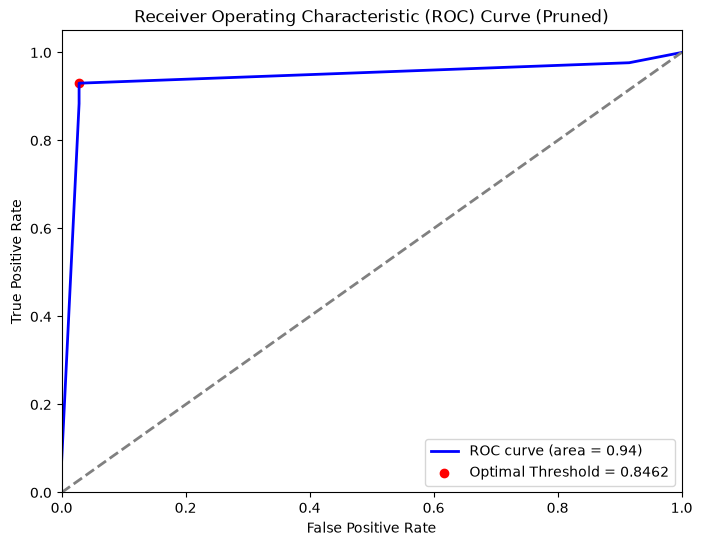

In [68]:
fpr_pruned, tpr_pruned, thresholds_pruned = roc_curve(y_test, y_pred_prob_dt_pruned)
roc_auc_pruned = auc(fpr_pruned, tpr_pruned)

# Compute Youden's J statistic for each threshold
youden_j_pruned = tpr_pruned - fpr_pruned
optimal_threshold_index_pruned = np.argmax(youden_j_pruned)
optimal_threshold_pruned = thresholds_pruned[optimal_threshold_index_pruned]

print(f"Optimal Threshold (Pruned): {optimal_threshold_pruned:.4f}")

# Plot ROC curve with the optimal threshold marked for the pruned model
plt.figure(figsize=(8, 6))
plt.plot(fpr_pruned, tpr_pruned, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_pruned:.2f})')
plt.scatter(fpr_pruned[optimal_threshold_index_pruned], tpr_pruned[optimal_threshold_index_pruned], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold_pruned:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Pruned)')
plt.legend(loc='lower right')
plt.show()

**Explanation of `param_grid` for performing GridSearchcv:**

- **'dt__max_depth'**:
  - **Values**: `[None, 10, 20, 30]`
  - **Meaning**: The maximum depth of the decision tree. If `None`, the nodes are expanded until all leaves are pure or until all leaves contain less than `min_samples_split` samples. Specific values (10, 20, 30) limit the depth of the tree to control its complexity and prevent overfitting.

- **'dt__min_samples_split'**:
  - **Values**: `[2, 5, 10]`
  - **Meaning**: The minimum number of samples required to split an internal node. Higher values prevent the model from learning overly specific patterns by requiring more samples for a split.

- **'dt__min_samples_leaf'**:
  - **Values**: `[1, 2, 4]`
  - **Meaning**: The minimum number of samples required to be at a leaf node. This parameter ensures that leaf nodes have a minimum number of samples, which helps prevent overfitting.

- **'dt__max_features'**:
  - **Values**: `[None, 'sqrt', 'log2']`
  - **Meaning**: The number of features to consider when looking for the best split:
    - `None`: Consider all features.
    - `'sqrt'`: Consider the square root of the total number of features.
    - `'log2'`: Consider the base-2 logarithm of the total number of features.
  - This parameter helps to reduce overfitting by considering fewer features.

- **'dt__ccp_alpha'**:
  - **Values**: `[0.0, 0.01, 0.1]`
  - **Meaning**: Complexity parameter used for Minimal Cost-Complexity Pruning. It controls the amount of pruning applied:
    - `0.0`: No pruning.
    - `0.01` and `0.1`: Apply pruning with increasing intensity, potentially reducing model complexity and preventing overfitting.

**Purpose:**

The `param_grid` dictionary is used by `GridSearchCV` to perform an exhaustive search over these hyperparameter values. `GridSearchCV` will train the model for each combination of the specified hyperparameters and evaluate their performance using cross-validation.

In [69]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the data
    ('dt', DecisionTreeClassifier(random_state=42))  # Decision Tree classifier
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4],
    'dt__max_features': [None, 'sqrt', 'log2'],
    'dt__ccp_alpha': [0.0, 0.01, 0.1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_}")

# Predict on the testing set with the best estimator
y_pred = grid_search.best_estimator_.predict(X_test)

# Calculate and print the testing accuracy
testing_accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {testing_accuracy}")

Best Parameters: {'dt__ccp_alpha': 0.0, 'dt__max_depth': None, 'dt__max_features': 'log2', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Best Cross-Validation Score: 0.9406593406593406
Testing Accuracy: 0.956140350877193


In [71]:
# Predict probabilities for ROC-AUC calculation
y_pred_prob_dt_pruned = pipeline_pruned.predict_proba(X_test)[:, 1]

In [72]:
# Print confusion matrix and classification report
conf_matrix_pruned = confusion_matrix(y_test, y_pred_test_dt_pruned)
print("Confusion Matrix (Pruned):")
print(conf_matrix_pruned)

print("Pruned Decision Trees Classification Report:")
print(classification_report(y_test, y_pred_test_dt_pruned))

Confusion Matrix (Pruned):
[[69  2]
 [ 3 40]]
Pruned Decision Trees Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Optimal Threshold (Pruned): 0.8462


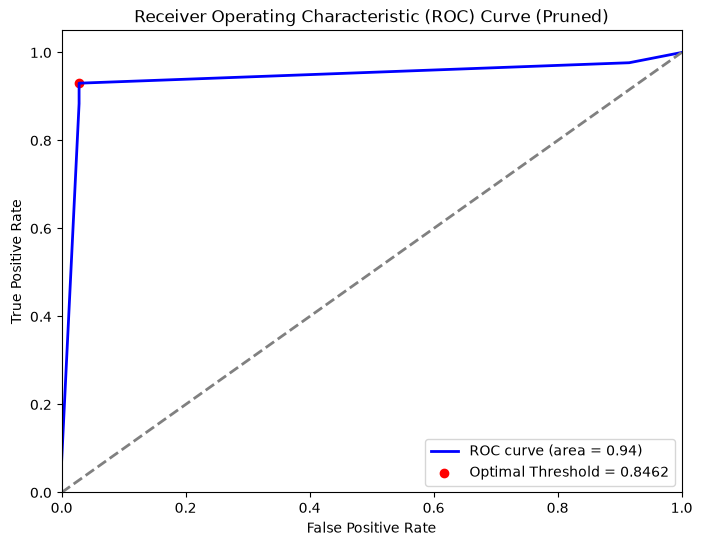

In [73]:
fpr_pruned, tpr_pruned, thresholds_pruned = roc_curve(y_test, y_pred_prob_dt_pruned)
roc_auc_pruned = auc(fpr_pruned, tpr_pruned)

# Compute Youden's J statistic for each threshold
youden_j_pruned = tpr_pruned - fpr_pruned
optimal_threshold_index_pruned = np.argmax(youden_j_pruned)
optimal_threshold_pruned = thresholds_pruned[optimal_threshold_index_pruned]

print(f"Optimal Threshold (Pruned): {optimal_threshold_pruned:.4f}")

# Plot ROC curve with the optimal threshold marked for the pruned model
plt.figure(figsize=(8, 6))
plt.plot(fpr_pruned, tpr_pruned, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_pruned:.2f})')
plt.scatter(fpr_pruned[optimal_threshold_index_pruned], tpr_pruned[optimal_threshold_index_pruned], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold_pruned:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Pruned)')
plt.legend(loc='lower right')
plt.show()

### __Observation:__

- Pruning the decision tree has successfully reduced overfitting, as indicated by the reduced training accuracy and improved testing accuracy.
- The pruned model shows more consistent cross-validation performance, indicating better stability and generalization.
- The overall classification metrics remain high, demonstrating that the pruned model maintains strong performance while avoiding the pitfalls of overfitting.

In [75]:
#Hyper Parameter Tuning in Decision Tree
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the data
    ('dt', DecisionTreeClassifier(random_state=42))  # Decision Tree classifier
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4],
    'dt__max_features': [None, 'sqrt', 'log2'],
    'dt__ccp_alpha': [0.0, 0.01, 0.1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_}")

# Predict on the testing set with the best estimator
y_pred = grid_search.best_estimator_.predict(X_test)

# Calculate and print the testing accuracy
testing_accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {testing_accuracy}")

Best Parameters: {'dt__ccp_alpha': 0.0, 'dt__max_depth': None, 'dt__max_features': 'log2', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Best Cross-Validation Score: 0.9406593406593406
Testing Accuracy: 0.956140350877193


In [76]:
# Import necessary libraries
from sklearn.svm import SVC

# Create a pipeline with a standard scaler and an SVM classifier
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the data
    ('svm', SVC(probability=True, random_state=42))  # SVM classifier with probability estimates
])

# Train the pipeline on the training data
pipeline_svm.fit(X_train, y_train)

# Predict on the training and testing set
y_pred_train_svm = pipeline_svm.predict(X_train)
y_pred_test_svm = pipeline_svm.predict(X_test)

# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_svm)
testing_accuracy = accuracy_score(y_test, y_pred_test_svm)
print("\nSupport Vector Machines (SVM)")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

# Predict probabilities for the test set
y_pred_prob_svm = pipeline_svm.predict_proba(X_test)[:, 1]



Support Vector Machines (SVM)
Training Accuracy: 0.989010989010989
Testing Accuracy: 0.9824561403508771


/home/indhu/Documents/ML Projects/Logistic_Regression/myenv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [77]:
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_svm,
    'Predicted Probability': y_pred_prob_svm
})

results_df.head()

,Actual Label,Predicted Label,Predicted Probability
204,0,0,0.020564
70,1,1,1.000000
131,1,1,0.999992
431,0,0,0.000158
540,0,0,0.000062


Confusion Matrix:
[[71  0]
 [ 2 41]]


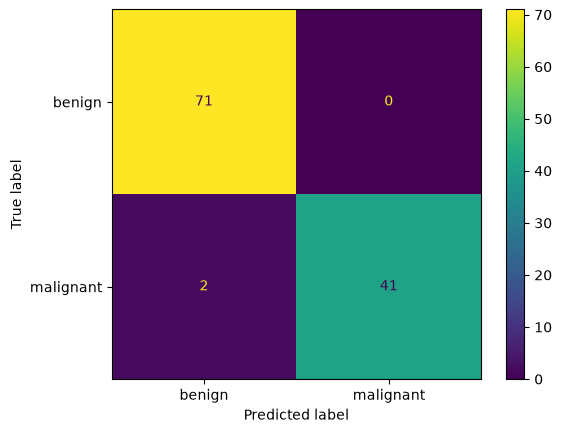

In [78]:
# Print confusion matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_test_svm)
print("Confusion Matrix:")
print(conf_matrix_svm)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_svm, display_labels = ["benign", "malignant"])
# display matrix
cm_display.plot()
plt.show()



In [79]:
# Print classification report
print("\t\tSupport Vector Machines Classification Report:")
print("\t\t------------------------------------------")
print(classification_report(y_test, y_pred_test_svm))

		Support Vector Machines Classification Report:
		------------------------------------------
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Optimal Threshold: 0.6821


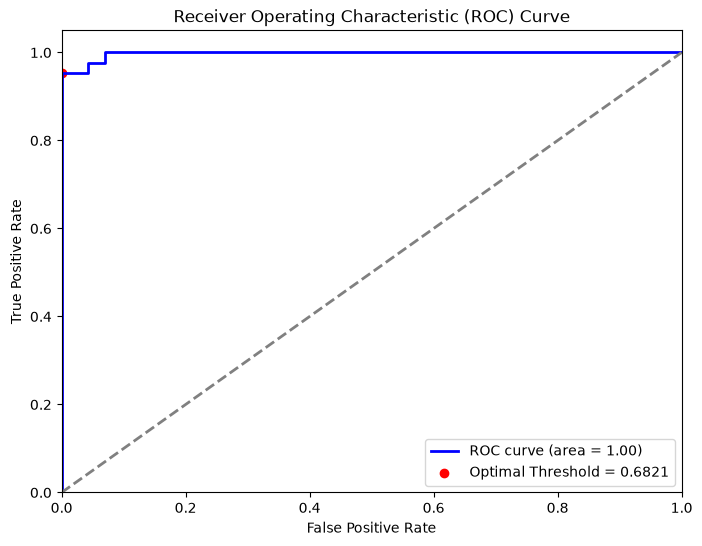

In [80]:
# Plot ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_svm)
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Conclusion:
   - Classification is a vital technique in supervised machine learning that focuses on identifying categorical outcomes based on given inputs. 

  - This problem has been introduced to  several key classification algorithms including Logistic Regression, Naive Bayes, K-Nearest Neighbors, Decision Trees, and Support Vector Machines,using the Breast Cancer dataset to illustrate real-world application.

 - Furthermore, learnings on how  to assess the effectiveness of these classification models using performance metrics such as accuracy, precision, recall, and the F1-score, alongside more comprehensive evaluations like ROC curves and confusion matrices has been done. Issues like overfitting and model tuning were  also addressed,enhancing the understanding of how to optimize model performance through hyperparameter adjustments.